In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

In [3]:
path_image = "../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

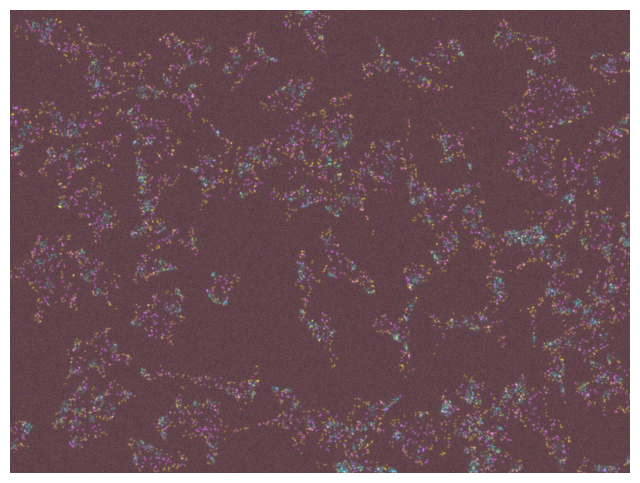

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image[2:, :, :])

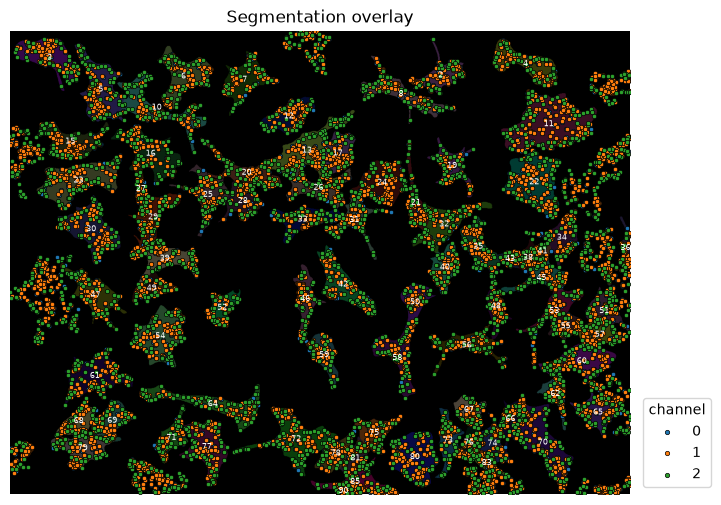

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [5]:
overlay_labels(label_mask=mask, coordinates=df_spots)

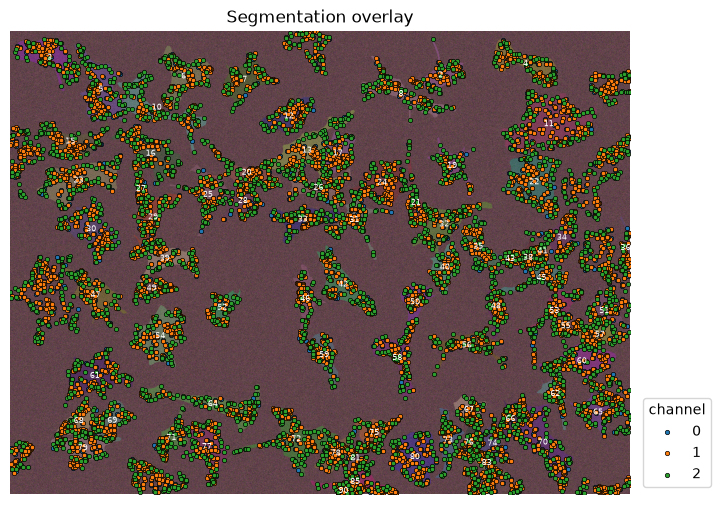

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [6]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=63
)

In [7]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)
print(df_cell)

      area  label
0   4669.0      2
1   7866.0      3
2   6945.0      4
3   9735.0      5
4   7749.0      6
..     ...    ...
72  9504.0     80
73  2878.0     81
74  1881.0     83
75  4198.0     85
76   441.0     90

[77 rows x 2 columns]


In [8]:
# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_spots)
print(df_cell)

       channel     y    x  label_cell
28           0   119  984           2
29           0    72  990           2
30           0   122  950           2
31           0   114  912           2
32           0    92  960           2
...        ...   ...  ...         ...
12607        2  1029  764          85
12670        2  1031  732          90
12671        2  1038  755          90
12672        2  1035  736          90
12673        2  1038  768          90

[10813 rows x 4 columns]
      area  label  count
0   4669.0      2     23
1   7866.0      3     39
2   6945.0      4     34
3   9735.0      5     48
4   7749.0      6     38
..     ...    ...    ...
72  9504.0     80     47
73  2878.0     81     14
74  1881.0     83      9
75  4198.0     85     20
76   441.0     90      2

[77 rows x 3 columns]


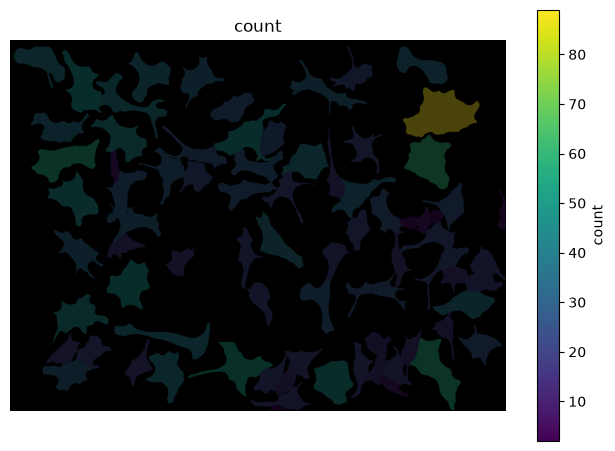

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [9]:
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

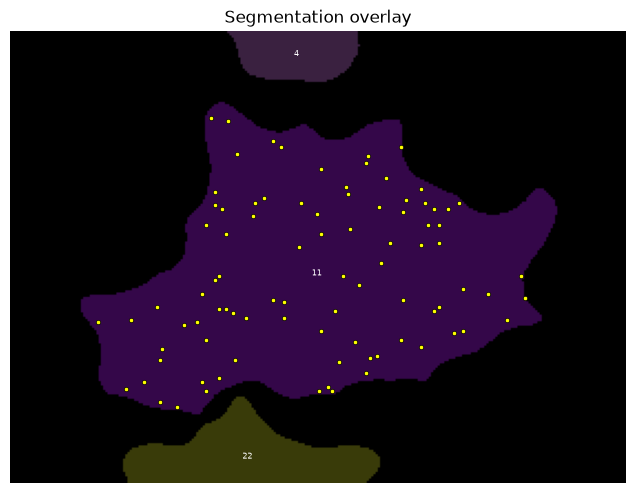

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [10]:
cell_id = 11
spots = df_spots.loc[(df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()

overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

In [11]:
def random_points_in_mask(mask, cell_label, n):
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

In [12]:
n_points = df_cell.loc[df_cell["label"] == cell_id]["count"].values[0]
print(n_points)

89


In [13]:
rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
rnd_points.shape

(89, 2)

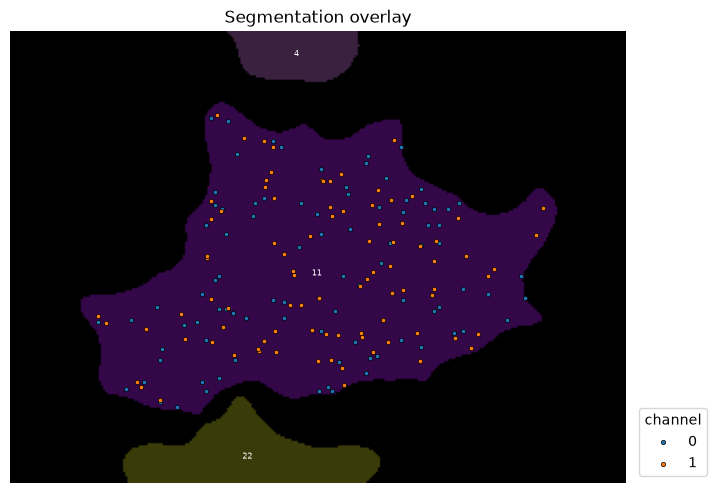

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [14]:
overlay_labels(label_mask=mask, coordinates=[spots, rnd_points], focus_object=cell_id)

In [15]:
dist_spots, _ = KDTree(spots).query(
    spots, k=2
)  # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_spots)

[[ 0.         11.40175425]
 [ 0.          5.09901951]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.          6.        ]
 [ 0.          8.06225775]
 [ 0.          5.83095189]
 [ 0.          6.32455532]
 [ 0.          4.47213595]
 [ 0.         13.41640786]
 [ 0.          3.16227766]
 [ 0.          9.89949494]
 [ 0.         10.81665383]
 [ 0.         14.86606875]
 [ 0.          6.08276253]
 [ 0.          7.        ]
 [ 0.          8.60232527]
 [ 0.          5.09901951]
 [ 0.          2.82842712]
 [ 0.          9.8488578 ]
 [ 0.          8.94427191]
 [ 0.          3.16227766]
 [ 0.          9.48683298]
 [ 0.         13.15294644]
 [ 0.         10.19803903]
 [ 0.         15.5241747 ]
 [ 0.         11.18033989]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.         11.40175425]
 [ 0.          7.28010989]
 [ 0.          6.08276253]
 [ 0.          8.24621125]
 [ 0.         10.19803903]
 [ 0.          4.47213595]
 [ 0.          3.60555128]
 [ 0.          3.16227766]
 

In [16]:
dist_rnd, _ = KDTree(rnd_points).query(
    rnd_points, k=2
)  # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_rnd)

[[ 0.          8.25335948]
 [ 0.          4.20343474]
 [ 0.          1.91796598]
 [ 0.          6.4660634 ]
 [ 0.          8.49843616]
 [ 0.          5.77654784]
 [ 0.          4.2099701 ]
 [ 0.         12.79555774]
 [ 0.          6.28174521]
 [ 0.          7.48959651]
 [ 0.         12.79555774]
 [ 0.          4.96697962]
 [ 0.          3.44929912]
 [ 0.          8.51849761]
 [ 0.          9.90641782]
 [ 0.          4.88771203]
 [ 0.          9.03172872]
 [ 0.          0.80863028]
 [ 0.          7.22643815]
 [ 0.         11.19486519]
 [ 0.          5.36712418]
 [ 0.          0.58670768]
 [ 0.          0.80863028]
 [ 0.          3.45167539]
 [ 0.          6.00507253]
 [ 0.          4.84482133]
 [ 0.          4.13151603]
 [ 0.          2.76745988]
 [ 0.          8.92573576]
 [ 0.          7.66576228]
 [ 0.          6.88487324]
 [ 0.          5.94590632]
 [ 0.          4.42876808]
 [ 0.          4.60876386]
 [ 0.          8.49843616]
 [ 0.          8.25335948]
 [ 0.          9.42730626]
 

In [17]:
spot_dist_avg = dist_spots[:, 1].mean()
rnd_dist_avg = dist_rnd[:, 1].mean()
print("Mean NN distance spots:", spot_dist_avg)
print("Mean NN distance random:", rnd_dist_avg)
print("Clark-Evans index (ratio):", spot_dist_avg / rnd_dist_avg)

Mean NN distance spots: 7.382794742295512
Mean NN distance random: 6.891200586662244
Clark-Evans index (ratio): 1.0713365036253244


In [18]:
n_repeats = 10

list_rnd_dist = []  # this list holds the average NN distances of the random points for each run
list_ce_index = []  # this list holds the Clark-Evans indices for each run


for _i in range(n_repeats):
    rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
    dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
    rnd_dist_avg = dist_rnd[:, 1].mean()
    list_rnd_dist.append(rnd_dist_avg)
    list_ce_index.append(spot_dist_avg / rnd_dist_avg)

print("Mean NN distance spots:", spot_dist_avg)
print(f"Mean NN distance spots ({n_repeats} runs):", np.array(list_rnd_dist).mean())
print(f"Mean Clark-Evans index ({n_repeats} runs):", np.array(list_ce_index).mean())

Mean NN distance spots: 7.382794742295512
Mean NN distance spots (10 runs): 7.625444544136494
Mean Clark-Evans index (10 runs): 0.9714468637022042


In [19]:
runs_rnd_smaller = np.array(list_rnd_dist) <= spot_dist_avg
print(runs_rnd_smaller)

[False  True  True  True False False False  True  True False]


In [20]:
pval = runs_rnd_smaller.mean()
print("p-value for CE index:", pval)

p-value for CE index: 0.5


In [21]:
def NNDist(spots, mask, cell_id, n_repeats):
    """
    Test whether spots in a cell are randomly distributed using nearest-neighbor
    distances and a Monte Carlo simulation of Complete Spatial Randomness (CSR).

    For each simulation run, n_repeats random point patterns are generated inside
    the cell mask and their mean nearest-neighbor distance is computed. The
    Clark-Evans index (observed / random NND) and a Monte Carlo p-value are
    derived from this null distribution.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    spot_dist_avg : float
        Mean nearest-neighbor distance of the observed spots.
    rnd_dist_avg : float
        Mean of the per-simulation mean nearest-neighbor distances under CSR.
    clark_evans : float
        Clark-Evans index: spot_dist_avg / rnd_dist_avg.
        < 1 indicates clustering, > 1 indicates dispersion.
    p_value : float
        Fraction of CSR simulations with mean NND <= spot_dist_avg.
        Small values (< 0.05) indicate significant clustering.
    """
    n_points = spots.shape[0]

    dist_spots, _ = KDTree(spots).query(spots, k=2)
    spot_dist_avg = dist_spots[
        :, 1
    ].mean()  # k=2: column 0 is self, column 1 is nearest neighbor

    list_rnd_dist = []
    list_ce_index = []
    for _i in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
        rnd_dist_avg = dist_rnd[:, 1].mean()
        list_rnd_dist.append(rnd_dist_avg)
        list_ce_index.append(spot_dist_avg / rnd_dist_avg)

    pval = (np.array(list_rnd_dist) <= spot_dist_avg).mean()

    return (
        spot_dist_avg,
        np.array(list_rnd_dist).mean(),
        np.array(list_ce_index).mean(),
        pval,
    )


NNDist(spots, mask, cell_id, 100)

(np.float64(7.382794742295512),
 np.float64(7.520875429531116),
 np.float64(0.9848822004134822),
 np.float64(0.34))

In [22]:
channel = 0
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,7.542691,8.750863,0.872532,0.0
1,7866.0,3,39,7.040435,7.556170,0.940801,0.2
2,6945.0,4,34,7.250944,7.804628,0.938208,0.3
3,9735.0,5,48,7.201960,7.605221,0.950748,0.2
4,7749.0,6,38,7.557600,8.255575,0.918817,0.1
...,...,...,...,...,...,...,...
72,9504.0,80,47,7.071116,7.398002,0.960594,0.2
73,2878.0,81,14,7.357530,7.730111,0.956877,0.3
74,1881.0,83,9,5.538022,8.000114,0.738517,0.1
75,4198.0,85,20,7.137660,9.115345,0.791996,0.0


In [23]:
df_cell.loc[df_cell["label"] == cell_id]

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
8,17915.0,11,89,7.382795,7.447827,0.996566,0.5


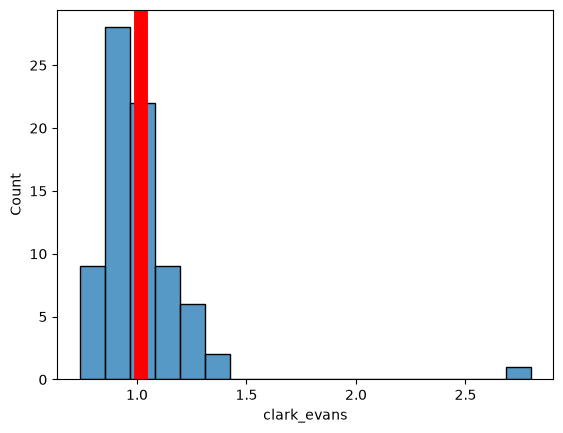

In [24]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

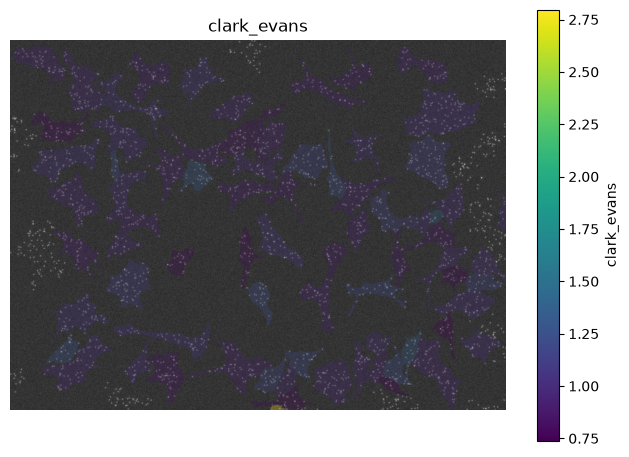

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [25]:
overlay_labels(
    image=image[2, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

In [26]:
channel = 1
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,3.854920,4.678378,0.830731,0.0
1,7866.0,3,39,4.270026,5.008054,0.855969,0.0
2,6945.0,4,34,4.445110,4.737956,0.943517,0.3
3,9735.0,5,48,4.891864,5.375425,0.915732,0.3
4,7749.0,6,38,4.489295,5.182078,0.870361,0.0
...,...,...,...,...,...,...,...
72,9504.0,80,47,4.367094,5.114473,0.857601,0.0
73,2878.0,81,14,3.344642,3.657404,0.920945,0.1
74,1881.0,83,9,2.414088,3.158512,0.769356,0.0
75,4198.0,85,20,3.384426,4.612141,0.736957,0.0


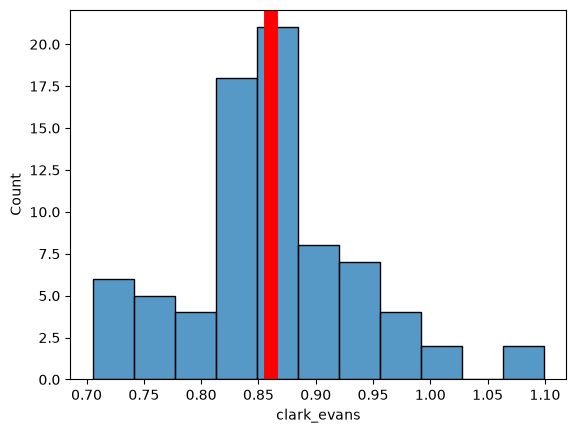

In [27]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

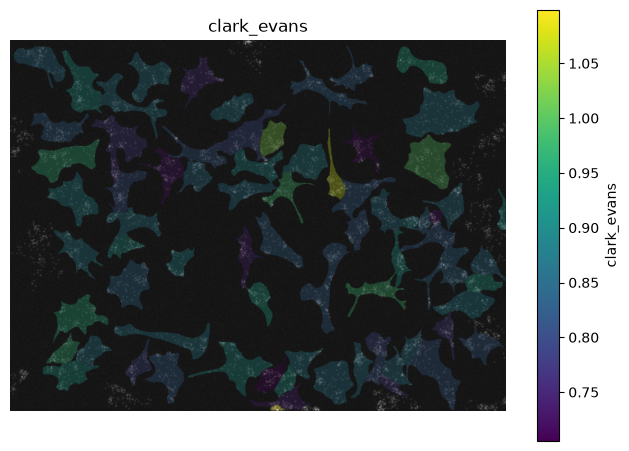

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [28]:
overlay_labels(
    image=image[3, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

In [29]:
channel = 2
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,6.870816,7.012814,0.996912,0.3
1,7866.0,3,39,7.355929,7.654600,0.963416,0.2
2,6945.0,4,34,6.231751,6.621079,0.949426,0.4
3,9735.0,5,48,6.240532,7.314284,0.856357,0.0
4,7749.0,6,38,6.343255,6.501991,0.981087,0.2
...,...,...,...,...,...,...,...
72,9504.0,80,47,6.363679,8.173773,0.782625,0.0
73,2878.0,81,14,6.751128,6.618215,1.035603,0.5
74,1881.0,83,9,7.651594,6.647742,1.168589,0.8
75,4198.0,85,20,6.427021,6.460272,1.008778,0.5


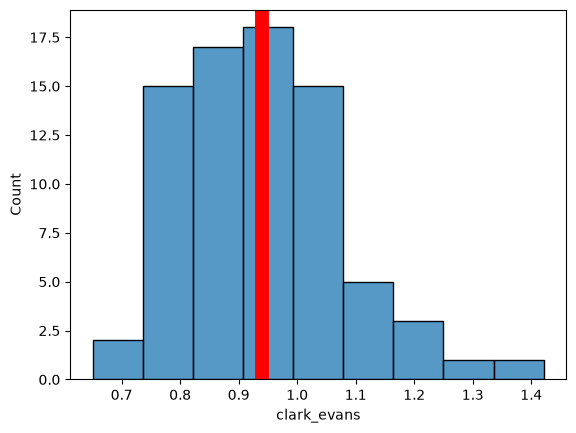

In [30]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

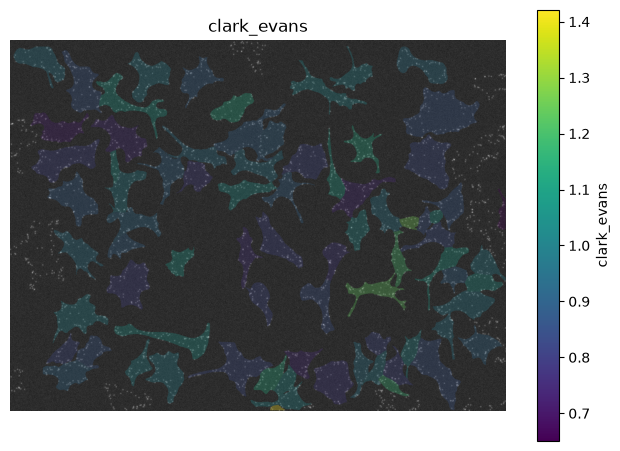

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [31]:
overlay_labels(
    image=image[4, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

In [32]:
from scipy.ndimage import binary_erosion


def RipleysL(spots, mask, cell_id, n_repeats, r_values=None):
    """
    Compute Ripley's L function for spots in a cell against a CSR null model,
    using a Monte Carlo envelope from simulated random point patterns.

    Returns the centered L function L(r) - r, which is 0 under CSR.
    Positive values indicate clustering at scale r, negative values indicate
    dispersion. Border correction is applied via mask erosion: only points at
    least r pixels from the cell boundary are used as source points.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.
    r_values : 1D array or None
        Radii at which to evaluate L(r) - r. Defaults to 30 values from 0
        to half the cell's effective radius.

    Returns
    -------
    r_values : 1D array
        Radii at which L(r) - r was evaluated.
    L_observed : 1D array
        L(r) - r for the observed spots.
    L_sims : (n_repeats, len(r_values)) array
        L(r) - r for each CSR simulation. Use .min(axis=0) / .max(axis=0)
        for the envelope, .mean(axis=0) for the expected value under CSR.
    """
    cell_mask = mask == cell_id
    area = cell_mask.sum()
    n_points = spots.shape[0]

    if r_values is None:
        r_max = np.sqrt(area / np.pi) * 0.5
        r_values = np.linspace(0, r_max, 30)

    # precompute eroded masks for each r — done once, not per simulation
    eroded_masks = []
    for r in r_values:
        r_int = int(np.ceil(r))
        size = 2 * r_int + 1
        cy, cx = np.ogrid[-r_int : size - r_int, -r_int : size - r_int]
        struct = cy**2 + cx**2 <= r**2
        eroded_masks.append(binary_erosion(cell_mask, structure=struct))

    def compute_L(coords):
        tree = KDTree(coords)
        K = []
        for r, eroded in zip(r_values, eroded_masks):
            valid = eroded[coords[:, 0].astype(int), coords[:, 1].astype(int)]
            n_valid = valid.sum()
            if n_valid == 0:
                K.append(np.nan)
                continue
            count = sum(len(tree.query_ball_point(p, r)) - 1 for p in coords[valid])
            K.append((area / (n_valid * n_points)) * count)
        return np.sqrt(np.array(K) / np.pi) - r_values

    L_observed = compute_L(spots)

    L_sims = []
    for _ in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        L_sims.append(compute_L(rnd_points))

    return r_values, L_observed, np.array(L_sims)

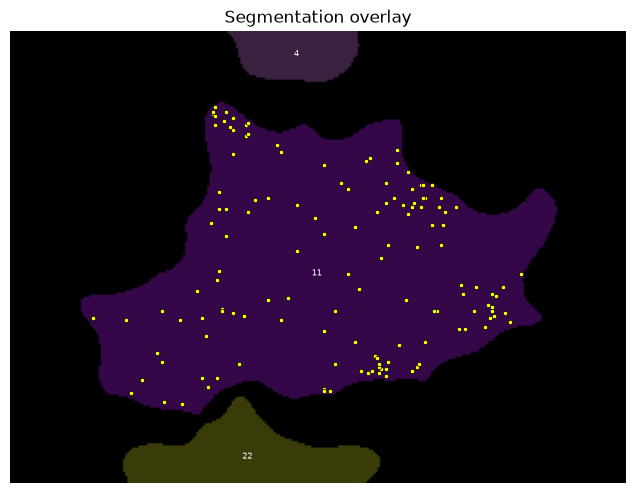

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [33]:
cell_id = 11
spots = df_spots.loc[(df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()
overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

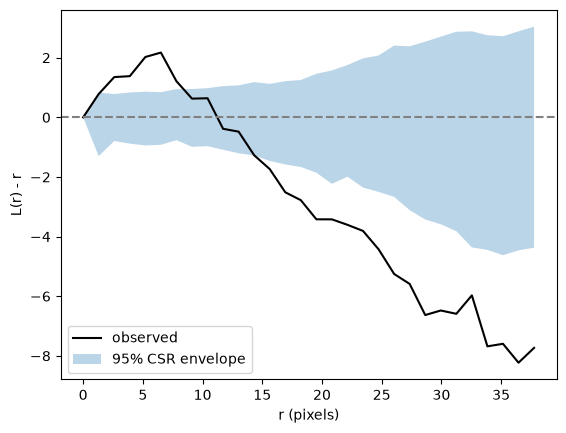

In [34]:
r_values, L_obs, L_sims = RipleysL(spots, mask, cell_id=11, n_repeats=200)

plt.plot(r_values, L_obs, color="black", label="observed")
plt.fill_between(
    r_values,
    np.percentile(L_sims, 2.5, axis=0),
    np.percentile(L_sims, 97.5, axis=0),
    alpha=0.3,
    label="95% CSR envelope",
)

plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("r (pixels)")
plt.ylabel("L(r) - r")
plt.legend()

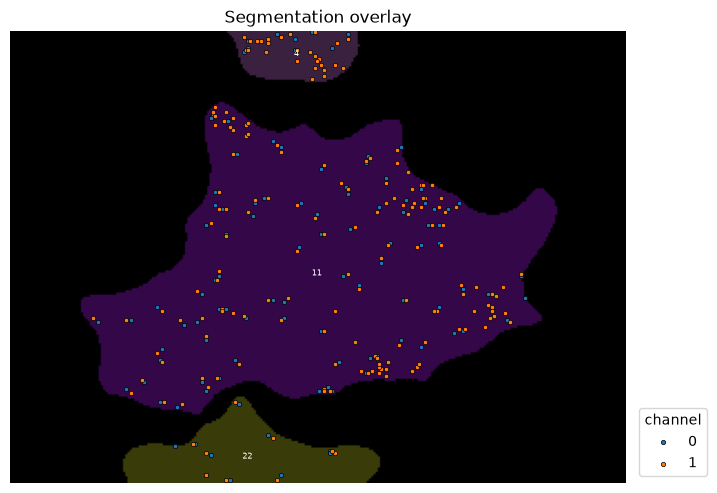

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [35]:
overlay_labels(
    label_mask=mask,
    coordinates=df_spots.loc[df_spots["channel"].isin([0, 1])],
    focus_object=cell_id,
)

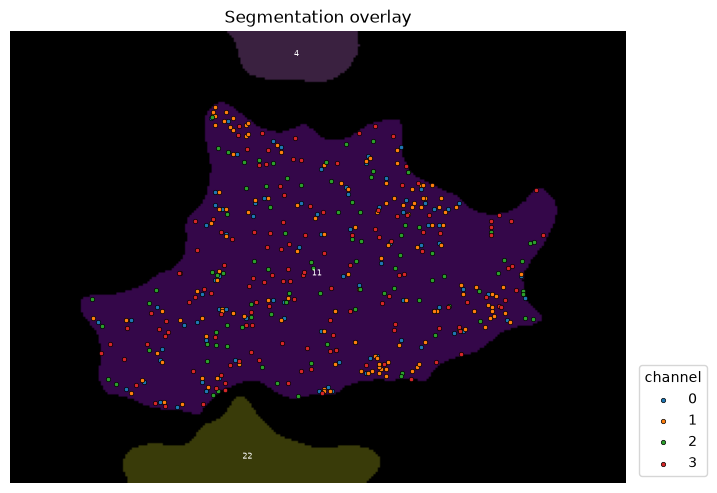

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [36]:
cell_id = 11
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

n_A, n_B = spots_A.shape[0], spots_B.shape[0]

rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)

overlay_labels(
    label_mask=mask, coordinates=[spots_A, spots_B, rnd_A, rnd_B], focus_object=cell_id
)

In [37]:
nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

nn_ArndB = KDTree(rnd_B).query(spots_A, k=1)[0].mean()
nn_BrndA = KDTree(rnd_A).query(spots_B, k=1)[0].mean()

print("Mean NN dist. A->B:", nn_AtoB)
print("Mean NN dist. B->A:", nn_BtoA)
print("Mean NN dist. A->random(B):", nn_ArndB)
print("Mean NN dist. B->random(A):", nn_BrndA)

Mean NN dist. A->B: 1.9655708446943665
Mean NN dist. B->A: 3.207888882211614
Mean NN dist. A->random(B): 5.817209323019758
Mean NN dist. B->random(A): 8.25372967404489


In [38]:
ce_AB = nn_AtoB / nn_ArndB
ce_BA = nn_BtoA / nn_BrndA

print("Clark-Evans index A->B:", ce_AB)
print("Clark-Evans index B->A:", ce_BA)

Clark-Evans index A->B: 0.33788896626364195
Clark-Evans index B->A: 0.3886593102630086


In [39]:
n_repeats = 100

sims_AtoB, sims_BtoA = [], []
for _ in range(n_repeats):
    rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
    rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
    sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
    sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

sims_AtoB = np.array(sims_AtoB)
sims_BtoA = np.array(sims_BtoA)

print("nn_AtoB", nn_AtoB)
print("nn_BtoA", nn_BtoA)
print("nn_random_AtoB", sims_AtoB.mean())
print("nn_random_BtoA", sims_BtoA.mean())
print("ce_AtoB", nn_AtoB / sims_AtoB.mean())
print("ce_BtoA", nn_BtoA / sims_BtoA.mean())
print("pval_AtoB", (sims_AtoB <= nn_AtoB).mean())
print("pval_BtoA", (sims_BtoA <= nn_BtoA).mean())

nn_AtoB 1.9655708446943665
nn_BtoA 3.207888882211614
nn_random_AtoB 5.929598016405687
nn_random_BtoA 7.612790842931971
ce_AtoB 0.3314846705048357
ce_BtoA 0.42138145502709434
pval_AtoB 0.0
pval_BtoA 0.0


In [40]:
def CrossNN(spots_A, spots_B, mask, cell_id, n_repeats):
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    The observed mean cross-NN distances are compared to a null distribution
    where both sets are independently randomized within the cell mask.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        "nn_AtoB": nn_AtoB,
        "nn_BtoA": nn_BtoA,
        "nn_random_AtoB": sims_AtoB.mean(),
        "nn_random_BtoA": sims_BtoA.mean(),
        "ce_AtoB": nn_AtoB / sims_AtoB.mean(),
        "ce_BtoA": nn_BtoA / sims_BtoA.mean(),
        "pval_AtoB": (sims_AtoB <= nn_AtoB).mean(),
        "pval_BtoA": (sims_BtoA <= nn_BtoA).mean(),
    }

In [41]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)

{'nn_AtoB': np.float64(1.9655708446943665),
 'nn_BtoA': np.float64(3.207888882211614),
 'nn_random_AtoB': np.float64(5.988228665228387),
 'nn_random_BtoA': np.float64(7.458180487428757),
 'ce_AtoB': np.float64(0.32823910952294955),
 'ce_BtoA': np.float64(0.4301168210689882),
 'pval_AtoB': np.float64(0.0),
 'pval_BtoA': np.float64(0.0)}

In [42]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    spots_A = df_spots.loc[
        (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()
    spots_B = df_spots.loc[
        (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        CrossNN(
            spots_A=spots_A,
            spots_B=spots_B,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,4669.0,2,23,6.870816,7.012814,0.996912,0.3,1.742602,5.578599,4.525745,9.003473,0.385042,0.619605,0.0,0.0
1,7866.0,3,39,7.355929,7.654600,0.963416,0.2,1.776632,3.954749,4.617370,7.376175,0.384771,0.536152,0.0,0.0
2,6945.0,4,34,6.231751,6.621079,0.949426,0.4,1.764162,5.842747,4.932676,7.457876,0.357648,0.783433,0.0,0.0
3,9735.0,5,48,6.240532,7.314284,0.856357,0.0,1.777044,4.682295,5.464139,7.420899,0.325219,0.630961,0.0,0.0
4,7749.0,6,38,6.343255,6.501991,0.981087,0.2,1.730490,6.242496,4.915231,7.695720,0.352067,0.811165,0.0,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,9504.0,80,47,6.363679,8.173773,0.782625,0.0,1.715710,3.593778,5.220712,8.069927,0.328635,0.445330,0.0,0.0
73,2878.0,81,14,6.751128,6.618215,1.035603,0.5,1.504764,7.685147,3.549184,8.185174,0.423974,0.938911,0.0,0.4
74,1881.0,83,9,7.651594,6.647742,1.168589,0.8,2.093022,10.883218,2.696991,8.018982,0.776058,1.357182,0.0,1.0
75,4198.0,85,20,6.427021,6.460272,1.008778,0.5,1.648309,6.056318,4.415560,7.848267,0.373296,0.771676,0.0,0.1


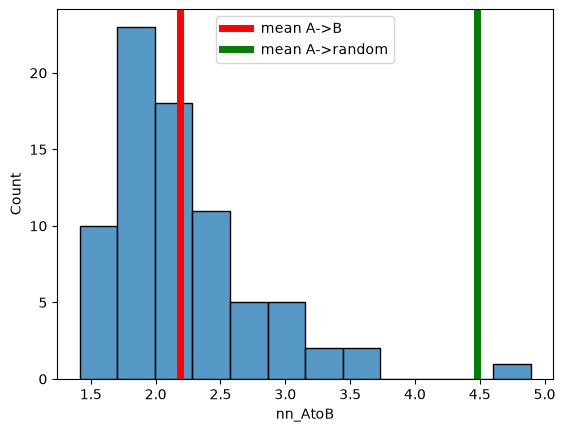

In [43]:
sns.histplot(
    df_cell,
    x="nn_AtoB",
)
plt.axvline(df_cell["nn_AtoB"].mean(), c="red", lw=5, label="mean A->B")
plt.axvline(df_cell["nn_random_AtoB"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

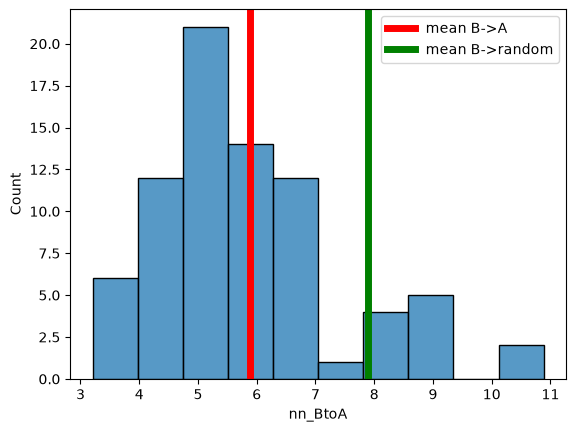

In [44]:
sns.histplot(
    df_cell,
    x="nn_BtoA",
)
plt.axvline(df_cell["nn_BtoA"].mean(), c="red", lw=5, label="mean B->A")
plt.axvline(df_cell["nn_random_BtoA"].mean(), c="green", lw=5, label="mean B->random")
plt.legend()

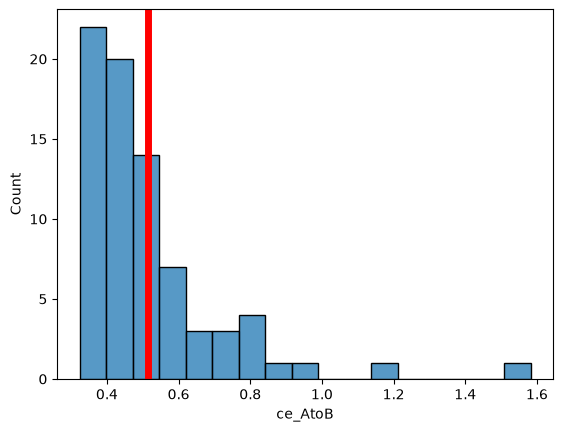

In [45]:
sns.histplot(
    df_cell,
    x="ce_AtoB",
)
plt.axvline(df_cell["ce_AtoB"].mean(), c="red", lw=5)

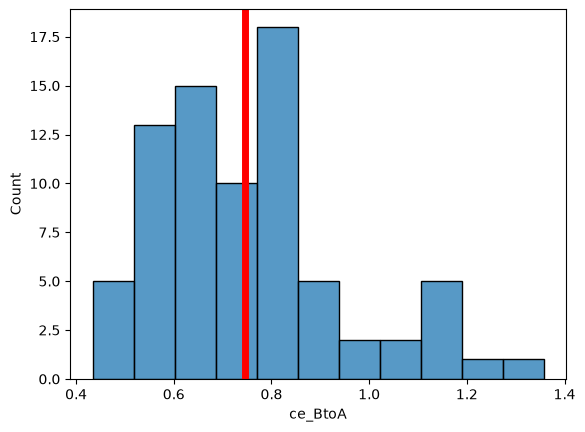

In [46]:
sns.histplot(
    df_cell,
    x="ce_BtoA",
)
plt.axvline(df_cell["ce_BtoA"].mean(), c="red", lw=5)

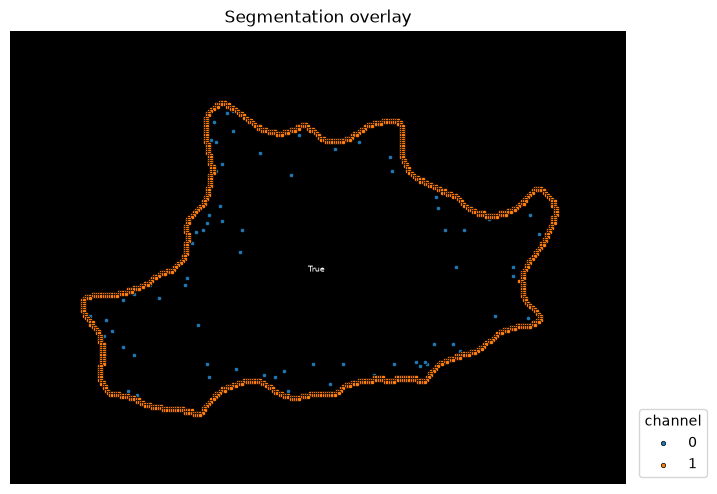

(<Figure size 800x588.571 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [47]:
from skimage.segmentation import find_boundaries

cell_id = 11

spots_C = df_spots.loc[
    (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

boundary = find_boundaries(mask == cell_id)
coords = np.argwhere(boundary)

overlay_labels(label_mask=boundary, coordinates=[spots_C, coords], focus_object=True)

In [48]:
def NNdist_target(spots_from, spots_to, mask, cell_id, n_repeats):
    """
    Calculate the nearest neighbour distance from `spots_from` to `spots_to`.
    """

    n_from = spots_from.shape[0]

    # observed NN distances
    nn_obs = KDTree(spots_to).query(spots_from, k=1)[0].mean()

    # randomised NN distances
    sims = []
    for _ in range(n_repeats):
        rnd = random_points_in_mask(mask, cell_label=cell_id, n=n_from)

        sims.append(KDTree(rnd_B).query(rnd, k=1)[0].mean())

    sims = np.array(sims)

    return {
        "nn_observed": nn_obs,
        "nn_random": sims.mean(),
        "ce": nn_obs / sims.mean(),
        "pval": (sims <= nn_obs).mean(),
    }

In [49]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    boundary = find_boundaries(mask == cell_id)
    coords = np.argwhere(boundary)
    spots_C = df_spots.loc[
        (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        NNdist_target(
            spots_from=spots_C,
            spots_to=coords,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_boundary = pd.DataFrame(results)
df_boundary

,nn_observed,nn_random,ce,pval
0,4.585573,192.612971,0.023807,0.0
1,4.553575,1035.800865,0.004396,0.0
2,5.152849,72.123925,0.071444,0.0
3,5.909423,915.477805,0.006455,0.0
4,5.043336,735.319837,0.006859,0.0
...,...,...,...,...
72,5.876321,726.314198,0.008091,0.0
73,5.066749,780.891596,0.006488,0.0
74,3.332884,705.859666,0.004722,0.0
75,3.951430,829.642817,0.004763,0.0


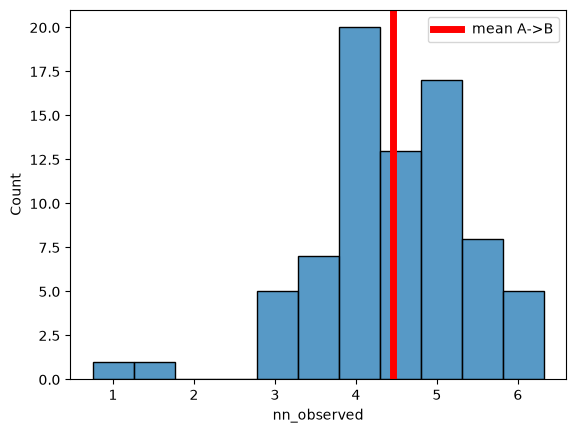

In [50]:
sns.histplot(
    df_boundary,
    x="nn_observed",
)
plt.axvline(df_boundary["nn_observed"].mean(), c="red", lw=5, label="mean A->B")
# plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

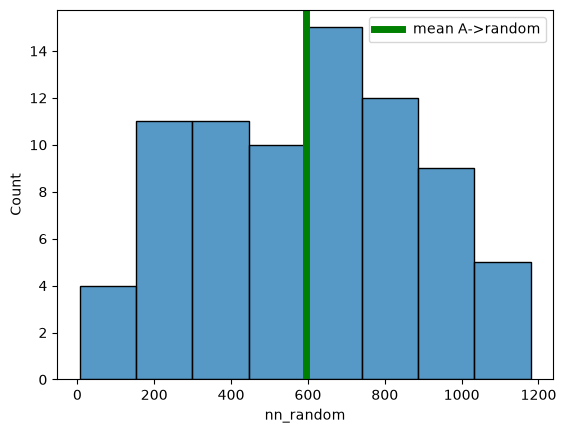

In [51]:
sns.histplot(
    df_boundary,
    x="nn_random",
)
# plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_boundary["nn_random"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

(0.0, 0.1)

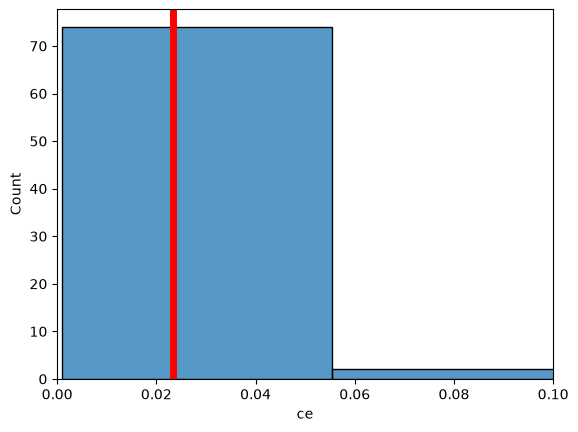

In [52]:
sns.histplot(
    df_boundary,
    x="ce",
)
plt.axvline(df_boundary["ce"].mean(), c="red", lw=5)
plt.xlim(0, 0.1)